In [142]:
import numpy as np
from typing import Tuple


class BanditEnv:
    """Multi-armed bandit environment"""

    def __init__(self, k: int) -> None:
        """__init__.

        Args:
            k (int): number of arms/bandits
        """
        self.k = k

    def reset(self) -> None:
        """Resets the mean payout/reward of each arm.
        This function should be called at least once after __init__()
        """
        # Initialize means of each arm distributed according to standard normal
        self.means = np.random.normal(0,1,size=self.k)

    def step(self, action: int) -> Tuple[float, int]:
        """Take one step in env (pull one arm) and observe reward

        Args:
            action (int): index of arm to pull
        """
        # TODO calculate reward of arm given by action
        reward = [np.random.normal(self.means[action],1), action] 

        return reward


In [206]:
import numpy as np
from abc import ABC, abstractmethod
from typing import Optional, Sequence


def argmax(arr: Sequence[float]) -> int:
    """Argmax that breaks ties randomly

    Takes in a list of values and returns the index of the item with the highest value, breaking ties randomly.

    Note: np.argmax returns the first index that matches the maximum, so we define this method to use in EpsilonGreedy and UCB agents.
    Args:
        arr: sequence of values
    """
    #arr.index(max(arr)) only returns first instance of max value
    #collects indices of all elements matching max value then randomly, uniformly, chooses one
    choices = [q for q in range(len(arr)) if arr[q] == max(arr)]
    return np.random.choice(choices)
    


class BanditAgent(ABC):
    def __init__(self, k: int, init: int, step_size: float) -> None:
        """Abstract bandit agent class

        Implements common functions for both epsilon greedy and UCB

        Args:
            k (int): number of arms
            init (init): initial value of Q-values
            step_size (float): step size
        """
        self.k = k
        self.init = init
        self.step_size = step_size

        # Q-values for each arm
        self.Q = None
        # Number of times each arm was pulled
        self.N = None
        # Current total number of steps
        self.t = None

    def reset(self) -> None:
        """Initialize or reset Q-values and counts

        This method should be called after __init__() at least once
        """
        #print("values reset")
        
        self.Q = self.init * np.ones(self.k, dtype=np.float32)
        self.N = np.zeros(self.k, dtype=int)
        self.t = 0

    @abstractmethod
    def choose_action(self) -> int:
        """Choose which arm to pull"""
        raise NotImplementedError

    @abstractmethod
    def update(self, action: int, reward: float) -> None:
        """Update Q-values and N after observing reward.

        Args:
            action (int): index of pulled arm
            reward (float): reward obtained for pulling arm
        """
        raise NotImplementedError


class EpsilonGreedy(BanditAgent):
    def __init__(
        self, k: int, init: int, epsilon: float, step_size: Optional[float] = None
    ) -> None:
        """Epsilon greedy bandit agent

        Args:
            k (int): number of arms
            init (init): initial value of Q-values
            epsilon (float): random action probability
            step_size (float or None): step size. If None, then it is equal to 1 / N_t (dynamic step size)
        """
        super().__init__(k, init, step_size)
        self.epsilon = epsilon

    def choose_action(self):
        """Choose which arm to pull

        With probability 1 - epsilon, choose the best action (break ties arbitrarily, use argmax() from above). With probability epsilon, choose a random action.
        """
        # list of 2 choices, best action from max Q value, and a random number in range of k actions
        actions = [argmax(self.Q), np.random.choice(range(0,self.k))]
        
        #print(f'actions: {actions}')
        # chooses between 2 possible action selections with epsilon probabilities
        
        action = np.random.choice(actions,p=[(1 - self.epsilon), self.epsilon])
        #print(f'action chosen: {action}')
        
        return action

    def update(self, action: int, reward: float) -> None:
        """Update Q-values and N after observing reward.

        Args:
            action (int): index of pulled arm
            reward (float): reward obtained for pulling arm
        """
        self.t += 1

        # TODO update self.N
        self.N[action]+=1
        
        #print(f'N(a): {self.N}')
        # TODO update self.Q
        # If step_size is given (static step size)
        
        if self.step_size is not None:
            self.Q[action] = self.Q[action] + self.step_size*(reward - self.Q[action])
            
        # If step_size is dynamic (step_size = 1 / N(a))
        else:
            #print(f'action taken a: {action}')
            #print(f'prev. Q(a): {self.Q}')
            #print(f'reward received R: {reward}')
            #print(f'1/N: {1/self.N[action]}')
            
            self.Q[action] = self.Q[action] + (1/self.N[action])*(reward - self.Q[action])
            #print(f'updated Q(a): {self.Q}')


class UCB(BanditAgent):
    def __init__(self, k: int, init: int, c: float, step_size: float) -> None:
        """Epsilon greedy bandit agent

        Args:
            k (int): number of arms
            init (init): initial value of Q-values
            c (float): UCB constant that controls degree of exploration
            step_size (float): step size (use constant step size in case of UCB)
        """
        super().__init__(k, init, step_size)
        self.c = c

    def choose_action(self):
        """Choose which arm to pull

        Use UCB action selection. Be sure to consider the case when N_t = 0 and break ties randomly (use argmax() from above)
        """
        # Determining the best action using the Uper-Confidence-Bound Action Selection
        
        # collect the inputs for all actions for argmax 
        actions = []
              
        # actions not tried yet get added to actions with the highest Q value, to create a list of selectable actions
        # if there are still untested actions it will randomly choose between best est. Q action and the Q=0 actions
        # eventually only the best Q est action will be in the list
        
        # test all actions with N(a) first then the best Q
        if 0 in self.N:
            for n in range(len(self.N)):
                if self.N[n] == 0:
                    actions.append(n)
            #print(f'zeros: {actions}')
            action = np.random.choice(actions)
        else: 
            #print(f'updates info: t={self.t} N(a)={self.N[action]} sqrt={np.sqrt(np.log(self.t)/self.N[action])}')
            # A_t = argmax_a (Q_t(a) + c*sqrt(ln(t) / N_t(a)))
            Q_=[0]*self.k
            for action in range(self.k):
                Q_[action] = self.Q[action] + (self.c * np.sqrt(np.log(self.t)/self.N[action]))
            action = argmax(Q_)
            
        #print(f'actions before argmax: {actions}') 
        
      
        #print(f'Qs input: {self.Q}')
        
        #print(f'argmax output: {argmax_out}')
        #print(f'actions: {actions}')
        #print(f'action taken: {action}')
        
        return action

    def update(self, action: int, reward: float) -> None:
        """Update Q-values and N after observing reward.

        Args:
            action (int): index of pulled arm
            reward (float): reward obtained for pulling arm
        """
        self.t += 1

        # TODO update self.N
        self.N[action]+=1
        
        #print(f'N(a): {self.N}')
        # TODO update self.Q
        #print(f'action taken a: {action}')
        #print(f'prev. Q(a): {self.Q}')
        #print(f'reward received R: {reward}')
        #print(f'1/N: {1/self.N[action]}')
        
        if self.step_size is not None:
            self.Q[action] = self.Q[action] + self.step_size*(reward - self.Q[action])
            
        # If step_size is dynamic (step_size = 1 / N(a))
        else:
            #print(f'action taken a: {action}')
            #print(f'prev. Q(a): {self.Q}')
            #print(f'reward received R: {reward}')
            #print(f'1/N: {1/self.N[action]}')
            
            self.Q[action] = self.Q[action] + (1/self.N[action])*(reward - self.Q[action])
            #print(f'updated Q(a): {self.Q}')

        #print(f'updated Q(a): {self.Q}')



In [167]:
#from env import BanditEnv
from tqdm import trange
import matplotlib.pyplot as plt


def q4(k: int, num_samples: int):
    """Q4

    Structure:
        1. Create multi-armed bandit env
        2. Pull each arm `num_samples` times and record the rewards
        3. Plot the rewards (e.g. violinplot, stripplot)

    Args:
        k (int): Number of arms in bandit environment
        num_samples (int): number of samples to take for each arm
    """

    env = BanditEnv(k=k)
    env.reset()

    actions = range(0,k)
    rewards = {}
    for a in actions:
        rewards[a] = []
        for i in range(0, num_samples):
            rewards[a].append(env.step(a)[0])
    plot_data=[]
    for a in rewards:
        plot_data.append(rewards[a])
    
    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    bp = ax.violinplot(plot_data)
    #plt.margins(x=0,y=0)
    plt.xlabel('Action')
    plt.xticks(range(1, k+1))
    plt.ylabel('Reward Distribution')
    plt.plot(list(range(k+2)),[0]*(k+2),':')
    plt.show()
    #return rewards


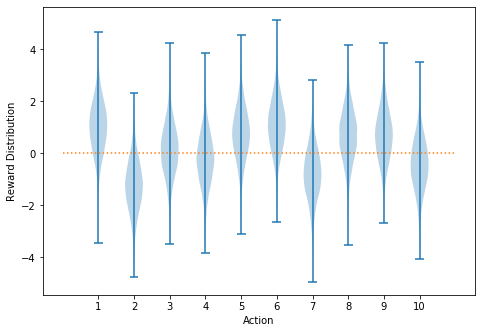

In [168]:
q4(k=10, num_samples=10000)

In [169]:
env = BanditEnv(10)

In [170]:
env.reset()
env.step(2)

[-0.7048971228231986, 2]

In [209]:
def q6(k: int, trials: int, steps: int):
    """Q6

    Implement epsilon greedy bandit agents with an initial estimate of 0

    Args:
        k (int): number of arms in bandit environment
        trials (int): number of trials
        steps (int): total number of steps for each trial
    """
    # TODO initialize env and agents here
    env = BanditEnv(k=k)
    agents = [EpsilonGreedy(k=k, init=0, epsilon=0.1), 
              EpsilonGreedy(k=k, init=0, epsilon=0.01), 
              EpsilonGreedy(k=k, init=0, epsilon=0)]

    # collect the max means of all arms in the environment over all trials, to find average later, then plot const line in rewards plot
    max_means = []
    #collect a running q max choice sum, keeping a sum and posting the current value each step for time time, by agent
    qmax_history = [[0]*steps,[0]*steps,[0]*steps]
    reward_history = [[0]*steps,[0]*steps,[0]*steps]
    
    # Loop over trials
    for t in trange(trials, desc="Trials", position=0, leave=True):
        #print(f'trial: {t}')
        # Reset environment and agents after every trial
        env.reset()
        
        # getting the value and index of the max q value for the trial
        max_means.append(max(env.means))
        max_id = list(env.means).index(max(env.means))
        history_a = [[0]*steps,[0]*steps,[0]*steps]
        rewards_a = [[0]*steps,[0]*steps,[0]*steps]
        
        #print(f'max mean value: {list(env.means).index(max(env.means))}, with value {max(env.means)}')
        for agent in agents:
            agent.reset()
            
        # TODO For each trial, perform specified number of steps for each type of agent
        
        for agent in agents:
            #print(f'agent: {agents.index(agent)}')
            optimal_count = 0
            for s in range(steps):
                action = agent.choose_action()
                
                # if the action is the optimal action add to the running sum
                if action == max_id:
                    optimal_count+=1
                # set history at step to whatever the running count for optimal action is
                # divide by the current step to get as a percentage of actions taken
                history_a[agents.index(agent)][s] = optimal_count / (s+1)
                
                reward = env.step(action)
                #print(f'reward at step {s} is reward {reward}')
                rewards_a[agents.index(agent)][s] = reward[0]
                
                agent.update(action, reward[0])
                
        #print(f'rewards over this trial: {rewards_a[agents.index(agent)]}')
        # take the history over this trial for each agent, and add it to the history for each agent, to have a sum for all trials 
        for agent in agents:
            qmax_history[agents.index(agent)] = list(map(lambda x, y: x + y, qmax_history[agents.index(agent)], history_a[agents.index(agent)]))
            reward_history[agents.index(agent)] = list(map(lambda x, y: x + y, reward_history[agents.index(agent)], rewards_a[agents.index(agent)]))

    
    # divide each entry for each agent at each step by trials to get a average
    for agent in agents:
        qmax_history[agents.index(agent)] = list(map(lambda x: x / trials, qmax_history[agents.index(agent)]))
        reward_history[agents.index(agent)] = list(map(lambda x: x / trials, reward_history[agents.index(agent)]))
        
    
    q_max = sum(max_means) / trials
    
    #calculating the standard error for rewards
    stderr_rewards = 1.96 * np.std(reward_history, axis=1) / np.sqrt(steps)
    #print(f'std err rewards {stderr_rewards}')
    
    fig, ax1 = plt.subplots(figsize=(15,8))
    # plotting the average reward for each agent
    ax1.plot(list(range(steps)), reward_history[0], linewidth=0.5)
    ax1.fill_between(list(range(steps)), 
                    reward_history[0]-stderr_rewards[0],
                    reward_history[0]+stderr_rewards[0],
                    alpha=0.2)
    
    ax1.plot(list(range(steps)), reward_history[1], linewidth=0.5)
    ax1.fill_between(list(range(steps)), 
                    reward_history[1]-stderr_rewards[1],
                    reward_history[1]+stderr_rewards[1],
                    alpha=0.2)
    
    ax1.plot(list(range(steps)), reward_history[2], linewidth=0.5)
    ax1.fill_between(list(range(steps)), 
                    reward_history[2]-stderr_rewards[2],
                    reward_history[2]+stderr_rewards[2],
                    alpha=0.2)
    
    # plotting the mean q max
    ax1.plot(list(range(steps)), [q_max]*steps)
    ax1.legend(['epsilon=0.1', 'epsilon=0.01', 'epsilon(greedy)=0.0', 'q_max mean'], loc='lower right')
    plt.xlabel("Steps")
    plt.ylabel("Average Reward")
 
    plt.savefig('average_reward_q6.pdf')
    plt.show()
    
    #calculating the standard error for optimal action
    stderr_opt_action = 1.96 * np.std(qmax_history, axis=1) / np.sqrt(steps)
    #print(f'std err opt act {stderr_opt_action}')
    
    fig, ax2 = plt.subplots(figsize=(15,8))
    
    # plotting the % Optimal Action for each agent
    ax2.plot(list(range(steps)), qmax_history[0])
    ax2.fill_between(list(range(steps)),
                    qmax_history[0]-stderr_opt_action[0],
                    qmax_history[0]+stderr_opt_action[0],
                    alpha=0.2)
    
    ax2.plot(list(range(steps)), qmax_history[1])
    ax2.fill_between(list(range(steps)),
                qmax_history[1]-stderr_opt_action[1],
                qmax_history[1]+stderr_opt_action[1],
                alpha=0.2)
    
    ax2.plot(list(range(steps)), qmax_history[2])
    ax2.fill_between(list(range(steps)),
                qmax_history[2]-stderr_opt_action[2],
                qmax_history[2]+stderr_opt_action[2],
                alpha=0.2)
    
    ax2.legend(['epsilon=0.1', 'epsilon=0.01', 'epsilon(greedy)=0.0'], loc='lower right')
    plt.xlabel("Steps")
    plt.ylabel("% Optimal Action")
    
    plt.savefig('percent_optimal_action_q6.pdf')
    plt.show()
    
    #return reward_history

Trials: 100%|██████████████████████████████████████████████████████████████████████| 2000/2000 [08:41<00:00,  3.83it/s]


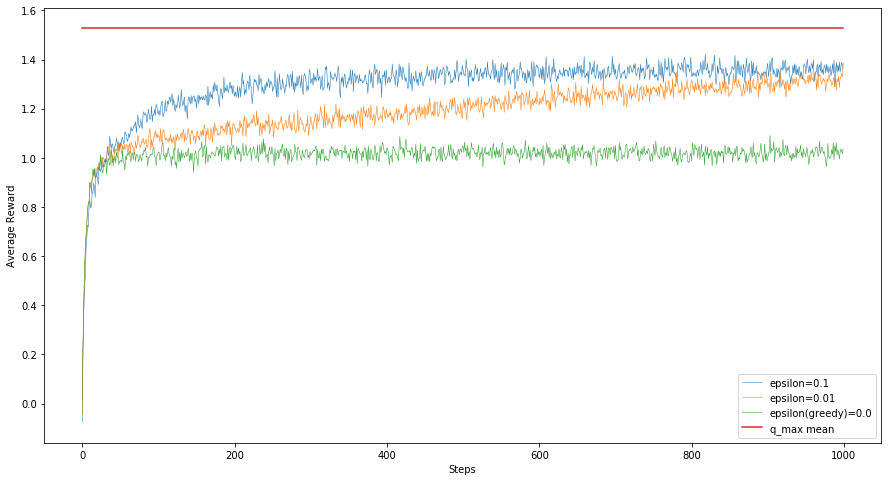

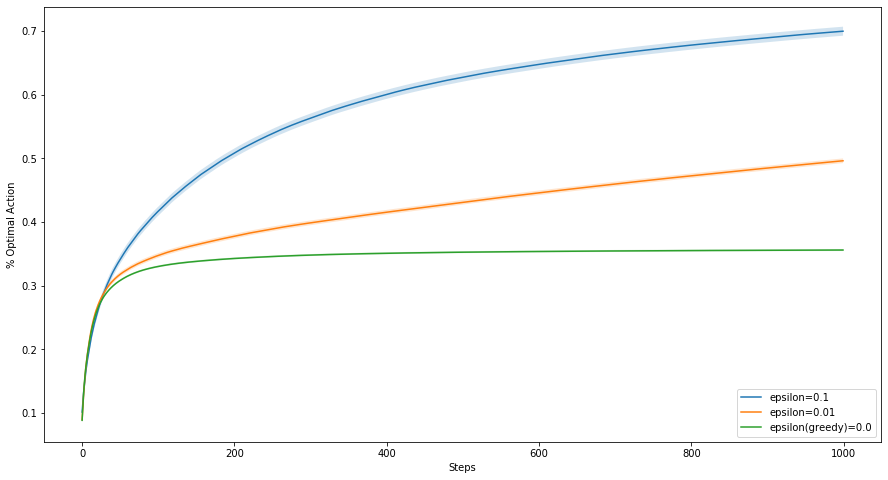

In [225]:
q6(10, 2000, 1000)

In [223]:
def q7(k: int, trials: int, steps: int):
    """Q7

    Compare epsilon greedy bandit agents and UCB agents

    Args:
        k (int): number of arms in bandit environment
        trials (int): number of trials
        steps (int): total number of steps for each trial
    """
    # TODO initialize env and agents here
    env = BanditEnv(k=k)
    agents = [EpsilonGreedy(k=k, init=0, epsilon=0, step_size=0.1),
             EpsilonGreedy(k=k, init=5, epsilon=0, step_size=0.1),
             EpsilonGreedy(k=k, init=0, epsilon=0.1, step_size=0.1),
             EpsilonGreedy(k=k, init=5, epsilon=0.1, step_size=0.1),
             UCB(k=k, init=0, c=2, step_size=0.1)]
    
    max_means = []
    qmax_history = [[0]*steps,[0]*steps,[0]*steps,[0]*steps,[0]*steps]
    reward_history = [[0]*steps,[0]*steps,[0]*steps,[0]*steps,[0]*steps]
    
    # Loop over trials
    for t in trange(trials, desc="Trials", position=0, leave=True):
        # Reset environment and agents after every trial
        env.reset()
        
        # getting the value and index of the max q value for the trial
        max_means.append(max(env.means))
        max_id = list(env.means).index(max(env.means))
        history_a = [[0]*steps,[0]*steps,[0]*steps,[0]*steps,[0]*steps]
        rewards_a = [[0]*steps,[0]*steps,[0]*steps,[0]*steps,[0]*steps]
        
        for agent in agents:
            agent.reset()

        # TODO For each trial, perform specified number of steps for each type of agent
        for agent in agents:
            optimal_count = 0
            #print(f'agent: {agents.index(agent)}')
            for s in range(steps):
                action = agent.choose_action()
                
                # if the action is the optimal action add to the running sum
                if action == max_id:
                    optimal_count+=1
                # set history at step to whatever the running count for optimal action is
                # divide by the current step to get as a percentage of actions taken
                history_a[agents.index(agent)][s] = optimal_count / (s+1)
                
                reward = env.step(action)
                rewards_a[agents.index(agent)][s] = reward[0]
                
                agent.update(action, reward[0])
                
        # take the history over this trial for each agent, and add it to the history for each agent, to have a sum for all trials 
        for agent in agents:
            qmax_history[agents.index(agent)] = list(map(lambda x, y: x + y, qmax_history[agents.index(agent)], history_a[agents.index(agent)]))
            reward_history[agents.index(agent)] = list(map(lambda x, y: x + y, reward_history[agents.index(agent)], rewards_a[agents.index(agent)]))

    # divide each entry for each agent at each step by trials to get a average
    for agent in agents:
        qmax_history[agents.index(agent)] = list(map(lambda x: x / trials, qmax_history[agents.index(agent)]))
        reward_history[agents.index(agent)] = list(map(lambda x: x / trials, reward_history[agents.index(agent)]))

    q_max = sum(max_means) / trials
    stderr_rewards = 1.96 * np.std(reward_history, axis=1) / np.sqrt(steps)
    
    fig, ax1 = plt.subplots(figsize=(15,8))
    
    ax1.plot(list(range(steps)), reward_history[0])
    ax1.fill_between(list(range(steps)), 
                    reward_history[0]-stderr_rewards[0],
                    reward_history[0]+stderr_rewards[0],
                    alpha=0.2)
    
    ax1.plot(list(range(steps)), reward_history[1])
    ax1.fill_between(list(range(steps)), 
                    reward_history[1]-stderr_rewards[1],
                    reward_history[1]+stderr_rewards[1],
                    alpha=0.2)
    
    ax1.plot(list(range(steps)), reward_history[2])
    ax1.fill_between(list(range(steps)), 
                    reward_history[2]-stderr_rewards[2],
                    reward_history[2]+stderr_rewards[2],
                    alpha=0.2)
    
    ax1.plot(list(range(steps)), reward_history[3])
    ax1.fill_between(list(range(steps)), 
                    reward_history[3]-stderr_rewards[3],
                    reward_history[3]+stderr_rewards[3],
                    alpha=0.2)
    
    ax1.plot(list(range(steps)), reward_history[4])
    ax1.fill_between(list(range(steps)), 
                    reward_history[4]-stderr_rewards[4],
                    reward_history[4]+stderr_rewards[4],
                    alpha=0.2)
    
    ax1.plot(list(range(steps)), [q_max]*steps)
    
    ax1.legend(['epsilon(greedy) (Q1=0,epsilon=0.0)', 
                'epsilon(greedy)(Q1=5,epsilon=0.0)',
                'epsilon (Q1=0,epsilon=0.1)',
                'epsilon (Q1=5,epsilon=0.1)',
                'UCB c=2',
                'q_max mean'], loc='lower right')
    plt.xlabel("Steps")
    plt.ylabel("Average Reward")  
    plt.savefig('average_reward_ucb.pdf')
    plt.show()
    
    stderr_opt_action = 1.96 * np.std(qmax_history, axis=1) / np.sqrt(steps)
    
    # plotting the % Optimal Action for each agent
    fig, ax2 = plt.subplots(figsize=(15,8))
    
    ax2.plot(list(range(steps)), qmax_history[0])
    ax2.fill_between(list(range(steps)),
                    qmax_history[0]-stderr_opt_action[0],
                    qmax_history[0]+stderr_opt_action[0],
                    alpha=0.2)
    
    ax2.plot(list(range(steps)), qmax_history[1])
    ax2.fill_between(list(range(steps)),
                    qmax_history[1]-stderr_opt_action[1],
                    qmax_history[1]+stderr_opt_action[1],
                    alpha=0.2)
    
    ax2.plot(list(range(steps)), qmax_history[2])
    ax2.fill_between(list(range(steps)),
                    qmax_history[2]-stderr_opt_action[2],
                    qmax_history[2]+stderr_opt_action[2],
                    alpha=0.2)
    
    ax2.plot(list(range(steps)), qmax_history[3])
    ax2.fill_between(list(range(steps)),
                    qmax_history[3]-stderr_opt_action[3],
                    qmax_history[3]+stderr_opt_action[3],
                    alpha=0.2)
    
    ax2.plot(list(range(steps)), qmax_history[4])
    ax2.fill_between(list(range(steps)),
                    qmax_history[4]-stderr_opt_action[4],
                    qmax_history[4]+stderr_opt_action[4],
                    alpha=0.2)
    
    ax2.legend(['epsilon(greedy) (Q1=0,epsilon=0.0)', 
                'epsilon(greedy)(Q1=5,epsilon=0.0)',
                'epsilon (Q1=0,epsilon=0.1)',
                'epsilon (Q1=5,epsilon=0.1)',
                'UCB c=2'], loc='lower right')
    plt.xlabel("Steps")
    plt.ylabel("% Optimal Action")
    plt.savefig('optimal_action_ucb.pdf')
    plt.show()

Trials: 100%|██████████████████████████████████████████████████████████████████████| 2000/2000 [14:33<00:00,  2.29it/s]


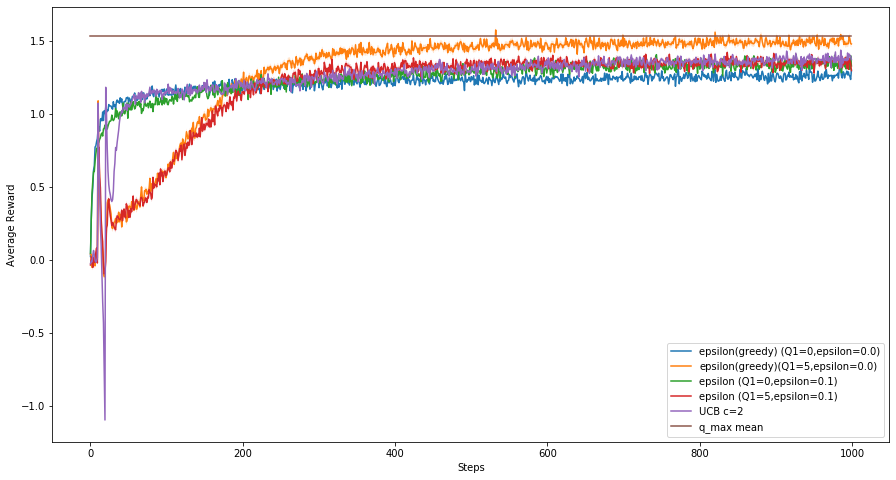

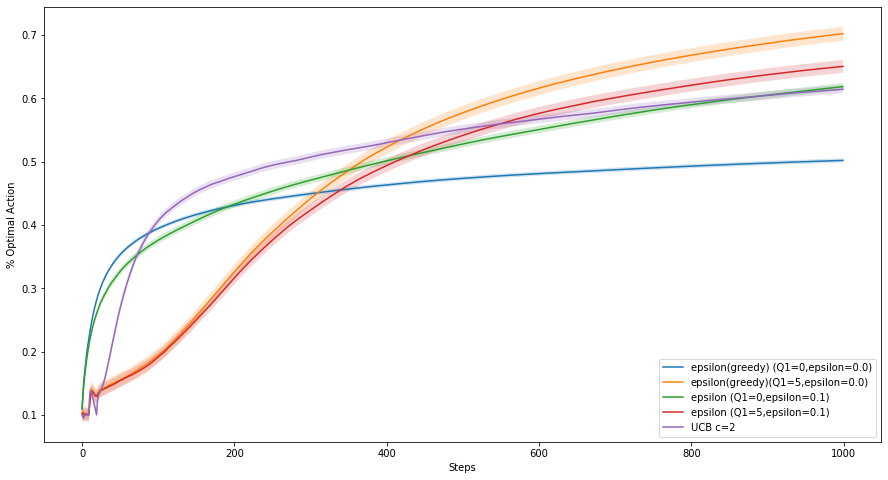

In [224]:
q7(10,2000,1000)